In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x : '%.4f' % x)
import sys
sys.path.append("..")

# Paquetes de visualización
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Importaciones de unidades de soporte
from SRC import sp_metrics

In [2]:
aviation_df = pd.read_csv('../data/joint_dataset_cleaning.csv')
aviation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 39 columns):
 #   Column                Dtype  
---  ------                -----  
 0   DATE                  object 
 1   YEAR                  int64  
 2   DAY                   int64  
 3   WEEKDAY               object 
 4   MONTH_NAME            object 
 5   AIRLINE_NAME          object 
 6   TAIL_NUMBER           object 
 7   FLIGHT_NUMBER         int64  
 8   SCHEDULED_DEPARTURE   object 
 9   DEPARTURE_TIME        object 
 10  DEPARTURE_DELAY       float64
 11  TAXI_OUT              float64
 12  WHEELS_OFF            float64
 13  SCHEDULED_TIME        float64
 14  SCHEDULED_TIME_HOURS  float64
 15  ELAPSED_TIME          float64
 16  AIR_TIME              float64
 17  AIR_TIME_HOURS        float64
 18  WHEELS_ON             float64
 19  TAXI_IN               float64
 20  ARRIVAL_TIME          object 
 21  ARRIVAL_DELAY         float64
 22  DELAYED               float64
 23  EXTREME

We are going to measure 3 dimensions in this analysis:
 - Punctuality (completed flights)
 - Reliability (cancellations & diversions)
 - Disruption impact (how severe diversions are)

In [3]:
# Creation of a flight status variable to classify them.

def classify_flight(row):
    if row["CANCELLED"] == 1:
        return "Cancelled"
    elif row["DIVERTED"] == 1:
        return "Diverted"
    else:
        return "Completed"

aviation_df["FLIGHT_STATUS"] = aviation_df.apply(classify_flight, axis=1)

In [4]:
# KPI - Cancellation Rate

cancellation_rate = (aviation_df["FLIGHT_STATUS"] == "Cancelled").mean()
print(f"{cancellation_rate:.2%}")

1.54%


- Roughly **1 in every 65 flights** gets cancelled.
- This is relatively low but operationally impactful at scale.

At a business level, even though the percentage is small, financially and reputationally it is significant. 

In [5]:
# KPI - Diversion Rate

diversion_rate = (aviation_df["FLIGHT_STATUS"] == "Diverted").mean()
print(f"{diversion_rate:.2%}")

0.26%


- About **1 in 385 flights** gets diverted.
- Much rarer than cancellations.

Diversions usually indicate:
- Weather issues
- Airport congestion
- Safety or operational constraints

They are rare but expensive and complex events.

In [6]:
# KPI - Total Disruption Rate

disruption_rate = cancellation_rate + diversion_rate
print(f"{disruption_rate:.2%}")

1.81%


Almost **2% of all flights do not complete as planned.**

That means:
- ~1 out of every 55 flights is either cancelled or diverted.

This is a strong high-level operational stability KPI.

In [7]:
# Punctuality KPIs

# Filter only completed flights (exclude Cancelled and Diverted)
completed_flights = aviation_df[aviation_df["FLIGHT_STATUS"] == "Completed"].copy()

In [8]:
# On-Time Performance (OTP): flights arriving within 15 minutes
completed_flights["ON_TIME"] = (completed_flights["ARRIVAL_DELAY"] <= 15).astype(int)

In [9]:
# Calculate punctuality metrics
otp_percentage = completed_flights["ON_TIME"].mean() * 100
average_arrival_delay = completed_flights["ARRIVAL_DELAY"].mean()
median_arrival_delay = completed_flights["ARRIVAL_DELAY"].median()

print(f"✅ Completed Flights Only:")
print(f"- On-time flights: {otp_percentage:.2f}%")
print(f"- Average arrival delay: {average_arrival_delay:.2f} min")
print(f"- Median arrival delay: {median_arrival_delay:.2f} min")

✅ Completed Flights Only:
- On-time flights: 82.09%
- Average arrival delay: 4.41 min
- Median arrival delay: -5.00 min


- Roughly **4 out of 5 flights arrive within 15 minutes of schedule.**
- This is a standard OTP (On-Time Performance) definition.

This is generally considered decent performance in aviation.

Average arrival delay & Median arrival delay:
- Median = -5 min -> Most flights arrive slightly early.
- Mean = +4.41 min -> But some flights are heavily delayed.

This indicates a **right-skewed distribution**.

Meaning:
- Many flights arrive early or slightly late
- A small percentage have very large delays
- Those extreme delays pull the average up

This is typical in aviation systems.

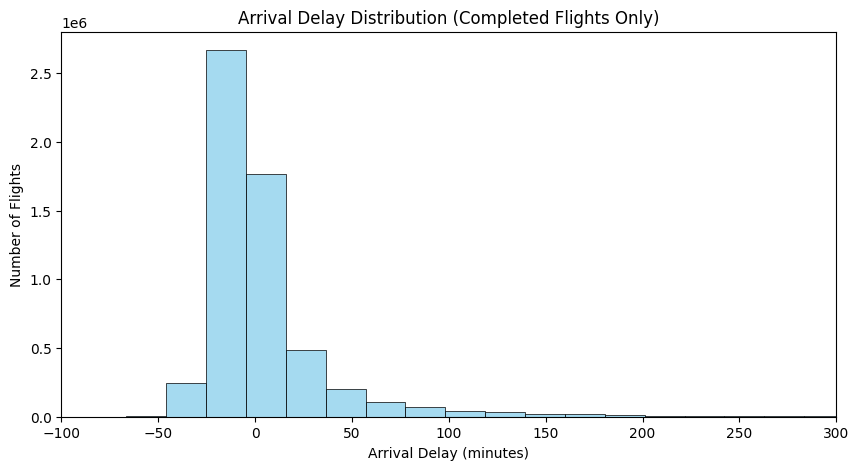

In [10]:
# Visualization of arrival delay distribution

plt.figure(figsize=(10,5))
sns.histplot(completed_flights["ARRIVAL_DELAY"], bins=100, color="skyblue")
plt.title("Arrival Delay Distribution (Completed Flights Only)")
plt.xlabel("Arrival Delay (minutes)")
plt.ylabel("Number of Flights")
plt.xlim(-100, 300)
plt.show()

In [11]:
# Creation of punctuality indicators

completed_flights["ON_TIME"] = (completed_flights["ARRIVAL_DELAY"] <= 15).astype(int)
completed_flights["DELAYED"] = (completed_flights["ARRIVAL_DELAY"] > 15).astype(int)
completed_flights["SEVERE_DELAY"] = (completed_flights["ARRIVAL_DELAY"] > 60).astype(int)

In [12]:
# Compute KPIs

otp = completed_flights["ON_TIME"].mean() * 100
delay_rate = 100 - otp
severe_delay_rate = completed_flights["SEVERE_DELAY"].mean() * 100

p90 = completed_flights["ARRIVAL_DELAY"].quantile(0.90)
p95 = completed_flights["ARRIVAL_DELAY"].quantile(0.95)

print(f"On-Time Performance (<=15 min): {otp:.2f}%")
print(f"Delay Rate (>15 min): {delay_rate:.2f}%")
print(f"Severe Delay Rate (>60 min): {severe_delay_rate:.2f}%")
print(f"90th Percentile Delay: {p90:.2f} minutes")
print(f"95th Percentile Delay: {p95:.2f} minutes")

On-Time Performance (<=15 min): 82.09%
Delay Rate (>15 min): 17.91%
Severe Delay Rate (>60 min): 5.58%
90th Percentile Delay: 34.00 minutes
95th Percentile Delay: 66.00 minutes


**On-Time Performance**:
- Roughly **4 out of 5 flights arrive on time** (industry standard definition).
- This indicates relatively strong operational reliability.
- The system performs well for the majority of passengers.

This is the primary airline KPI.

An OTP of ~82% suggests:
- Stable scheduling
- Reasonable buffer management
- Some operational friction, but not systemic breakdown

**Delay Rate**:
- Nearly **1 in 5 flights experiences a meaningful delay.**

This means delays are not rare - they are a recurring operational reality.

This percentage is large enough to:
- Affect passenger satisfaction
- Create connection risk
- Generate cascading effects across the network

**Severe Delay Rate**:
- About **1 in 18 flights suffers a severe delay**
- This is a subset of delayed flights

If we break it down:
- Total delayed flights: 17.91%
- Severe delays: 5.58%
- Roughly **31% of delayed flights become severe delays**

Severe delay meaning:
- Drive most customer complaints
- Cause missed connections
- Increase compensation costs
- Create operational recovery challenges

Even though only 5.6% overall, they are disproportionately impactful.

**90th percentile delay: 34 minutes**:
- 90% of flights arrive with delay ≤ 34 minutes.
- Only 10% exceed this.
- Most delays are moderate.
- Long delays are not the norm.

**95th percentile delay: 66 minutes**:
- 95% of flights arrive with delay ≤ 66 minutes.
- Only 5% exceed 66 minutes.
- That confirms the severe threshold is logically consistent with the distribution.


/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_23141/2841923436.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


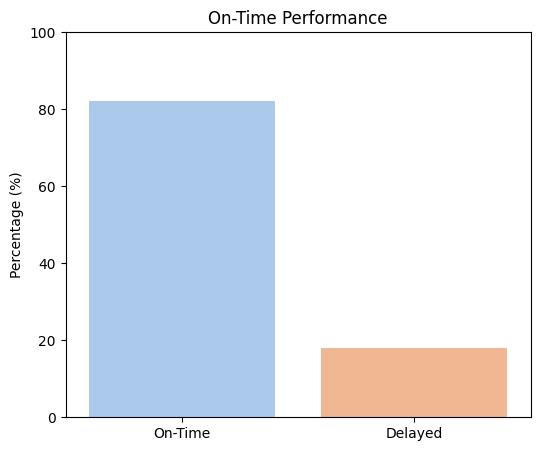

In [13]:
# Visualization On-Time Performance

plt.figure(figsize=(6,5))

sns.barplot(
    x=["On-Time", "Delayed"],
    y=[otp, delay_rate],
    palette="pastel"
)

plt.title("On-Time Performance")
plt.ylabel("Percentage (%)")
plt.ylim(0,100)
plt.show()

In [14]:
# Filtration of diverted flights

diverted = aviation_df[aviation_df["FLIGHT_STATUS"] == "Diverted"].copy()

diverted.shape

(15187, 40)

In [15]:
# Departure delay before diversion

avg_dep_delay_div = diverted["DEPARTURE_DELAY"].mean()
median_dep_delay_div = diverted["DEPARTURE_DELAY"].median()

print(f"Average Departure Delay Before Diversion: {avg_dep_delay_div:.2f} minutes")
print(f"Median Departure Delay Before Diversion: {median_dep_delay_div:.2f} minutes")

Average Departure Delay Before Diversion: 25.89 minutes
Median Departure Delay Before Diversion: 2.00 minutes


- Median = 2 min -> Most diverted flights departed almost on time.
- Mean = 25.89 min -> Some diverted flights were heavily delayed before departure.

Diversions are **not primarily caused by departure delays.**

Instead, likely causes:
- En-route weather
- Destination congestion
- Mechanical issues
- Airspace restrictions

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_23141/3589248102.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


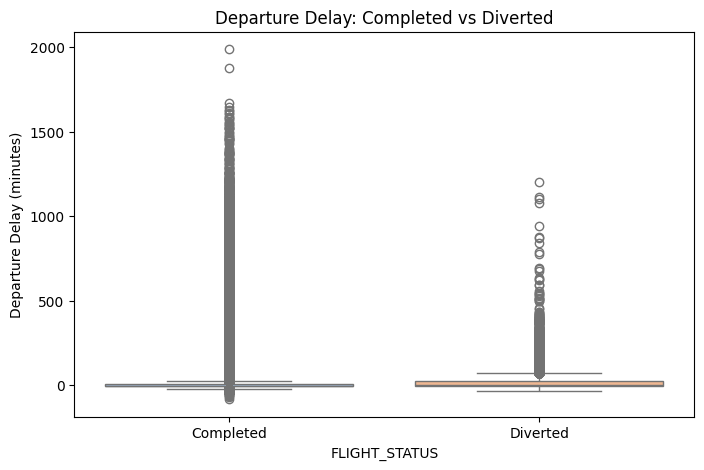

In [16]:
# Comparison departure delay (completed flights vs diverted flights)

plt.figure(figsize=(8,5))

sns.boxplot(
    x="FLIGHT_STATUS",
    y="DEPARTURE_DELAY",
    data=aviation_df[aviation_df["FLIGHT_STATUS"].isin(["Completed","Diverted"])],
    palette="pastel"
)

plt.title("Departure Delay: Completed vs Diverted")
plt.ylabel("Departure Delay (minutes)")
plt.show()

In [17]:
# Airport diversion patterns

top_airports = (
    diverted["AIRPORT_ORIGIN"]
    .value_counts(normalize=True)
    .head(10) * 100
)

top_airports

AIRPORT_ORIGIN
UNKNOWN                                            5.4850
Chicago O'Hare International Airport               5.1491
Hartsfield-Jackson Atlanta International Airport   5.0899
Dallas/Fort Worth International Airport            4.2800
Denver International Airport                       3.4898
Los Angeles International Airport                  3.3318
George Bush Intercontinental Airport               3.1145
Gen. Edward Lawrence Logan International Airport   2.5614
San Francisco International Airport                2.4297
Phoenix Sky Harbor International Airport           2.3770
Name: proportion, dtype: float64

Top airports include:
- Chicago O'Hare International Airport
- Hartsfield-Jackson Atlanta International Airport
- Dallas/Fort Worth International Airport
- Denver International Airport
- Los Angeles International Airport
- San Francisco International Airport

Interpretation could be these are:
- Major hub airports
- High-traffic
- Complex airspace environments

Diversions are concentrated in:
- High-volume hubs
- Weather-sensitive locations (Chicago, Denver)
- Congestion-prone airports

This suggests diversions are more correlated with operational complexity and traffic volume than random events. 

/var/folders/r8/sbs1vswj5qb9kjwlkhpfxj4c0000gn/T/ipykernel_23141/4291093611.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


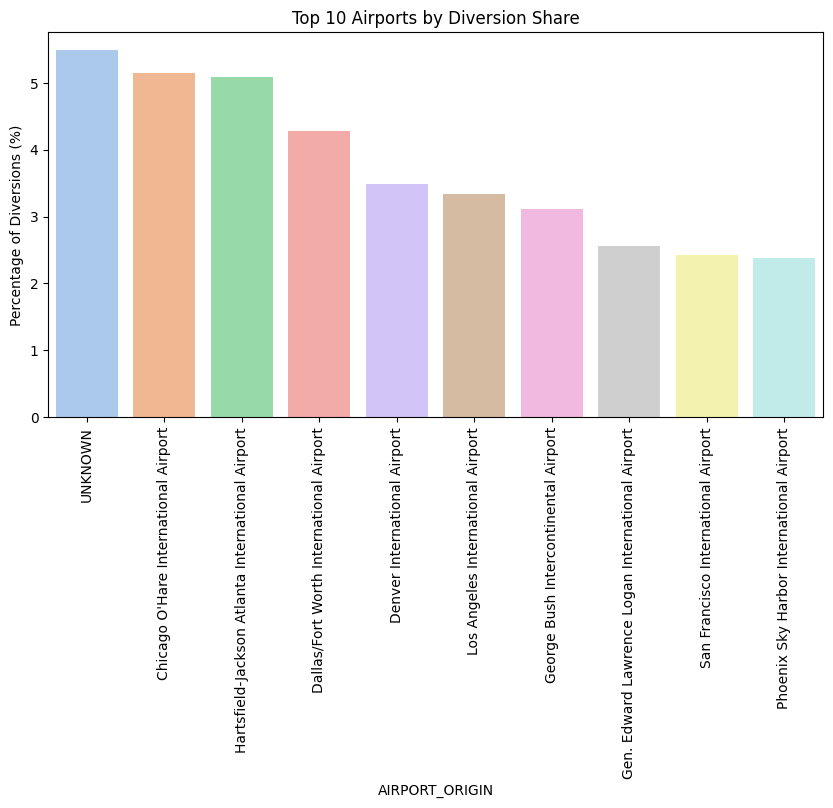

In [18]:
# Visualization diversion airports

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_airports.index,
    y=top_airports.values,
    palette="pastel"
)

plt.xticks(rotation=90)
plt.title("Top 10 Airports by Diversion Share")
plt.ylabel("Percentage of Diversions (%)")
plt.show()

The flight network operates reliably for the majority of passengers, with over 82% of flights arriving on time. However, nearly 18% experience delays, and about 1 in 18 flights suffers a severe delay exceeding one hour. The delay distribution is strongly right-skewed, meaning operational risk is driven by a small proportion of extreme disruption events rather than widespread systemic lateness.

In [19]:
# Delay Distribution Breakdown

# Define delay bins
bins = [-np.inf, 0, 15, 30, 60, 120, np.inf]

labels = [
    "Early (<0)",
    "On Time (0-15)",
    "Moderate (15-30)",
    "Significant (30-60)",
    "Severe (60-120)",
    "Extreme (>120)"
]

# Create categorical delay bucket column

completed_flights["DELAY_BUCKET"] = pd.cut(
    completed_flights["ARRIVAL_DELAY"],
    bins=bins,
    labels=labels
)

# Calculate percentage distribution

delay_distribution = (
    completed_flights["DELAY_BUCKET"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

delay_distribution_percent = (
    delay_distribution.round(2).astype(str) + "%"
)

delay_distribution_percent


DELAY_BUCKET
Early (<0)             63.48%
On Time (0-15)         18.61%
Moderate (15-30)        6.84%
Significant (30-60)     5.49%
Severe (60-120)         3.58%
Extreme (>120)           2.0%
Name: proportion, dtype: object

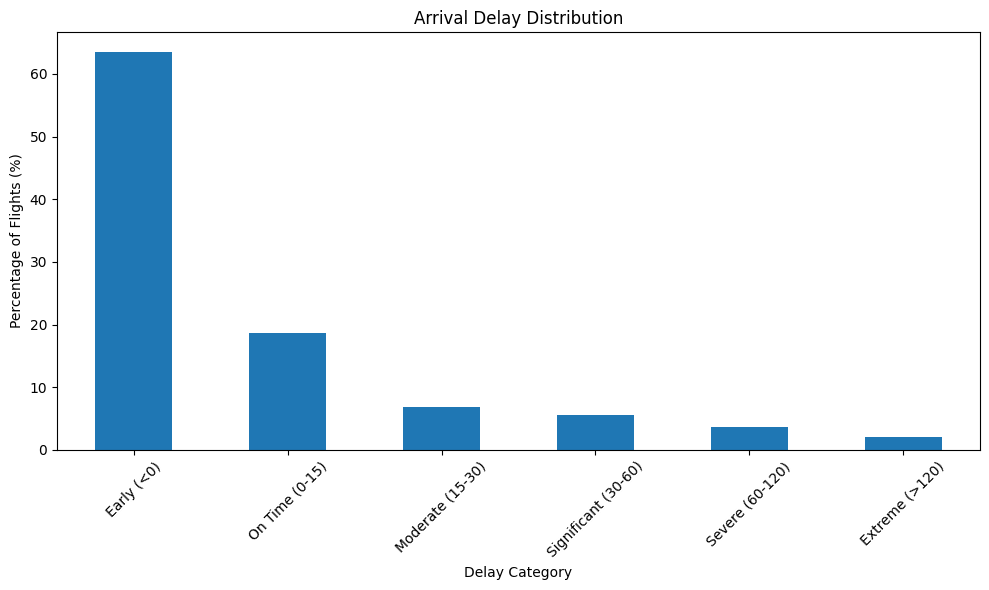

In [20]:
# Visualization of the delay distribution

plt.figure(figsize=(10, 6))

delay_distribution.plot(kind="bar")

plt.title("Arrival Delay Distribution")
plt.xlabel("Delay Category")
plt.ylabel("Percentage of Flights (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Overall Reliability Structure**

**63.48% of flights arrive early.**

It is very high and suggests that:
- Airlines schedule conservatively
- Built-in buffer time exists
- Block times may include operational slack

When combined with the **18.61% arriving within 15 minutes**, we get 82,09% On-Time Performance. This confirms the earlier KPI and shows internal consistency.

**Clear Right-Skewed Distribution**

Notice the structural pattern:
- Very large mass on the left (early arrivals)
- Gradual decline as delay severity increases
- Small but persistent extreme tail

This is classic right-skewed behavior:
- Most flights are early or slightly delayed
- A small minority experience very large delays
- Those extreme values pull the mean upward

**Moderate vs Significant Delays**

Breakdown:
- 6.84% moderate (15-30 min)
- 5.49% significant (30-60 min)

Together, 12.33% of flights experience delays between 15 and 60 minutes.

This shows that:
- The majority of delays are not catastrophic
- Most delayed flights fall in the "operational friction" range
- The system absorbs disturbances reasonably well

**Severe and Extreme Delays (Tail Risk)**

- Severe (60-120): 3.58%
- Extreme (>120): 2.00%

5.58% of flights experience delays greater than 1 hour.

Although severe delays affect a minority of flights, they are operationally critical because:
- They drive passenger dissatisfaction
- They increase missed connections
- They generate cascading network effects
- They likely account for disproportionate economic cost

This is the **risk concentration effect.**

**Structural Interpretation of the System**

**The system is generally stable**

Large majority of flights arrive early or close to schedule.

**The system experiences regular moderate friction**

About 12% fall into mid-range delays (15-60 min).

**The system has a small but meaningful disruption tail**

About 1 in 18 flights experience severe delay (>60 min).

This is typical of complex transportation networks:
- Stable under normal conditions
- Vulnerable to occasional high-impact events

In [21]:
# Root cause contribution

# List of delay cause columns

delay_causes = [
    "AIR_SYSTEM_DELAY",
    "WEATHER_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "SECURITY_DELAY"
]

# Sum total minutes per cause
total_delay_by_cause = completed_flights[delay_causes].sum()

total_delay_by_cause

AIR_SYSTEM_DELAY      14335762.0000
WEATHER_DELAY          3100233.0000
AIRLINE_DELAY         20172956.0000
LATE_AIRCRAFT_DELAY   24961931.0000
SECURITY_DELAY           80985.0000
dtype: float64

In [22]:
# Convert to percentage contribution

# Calculate percentage contribution
delay_cause_percentage = (
    total_delay_by_cause / total_delay_by_cause.sum() * 100
).round(2)

delay_cause_percentage_formatted = (
    delay_cause_percentage.astype(str) + "%"
)

delay_cause_percentage_formatted

AIR_SYSTEM_DELAY       22.88%
WEATHER_DELAY           4.95%
AIRLINE_DELAY           32.2%
LATE_AIRCRAFT_DELAY    39.84%
SECURITY_DELAY          0.13%
dtype: object

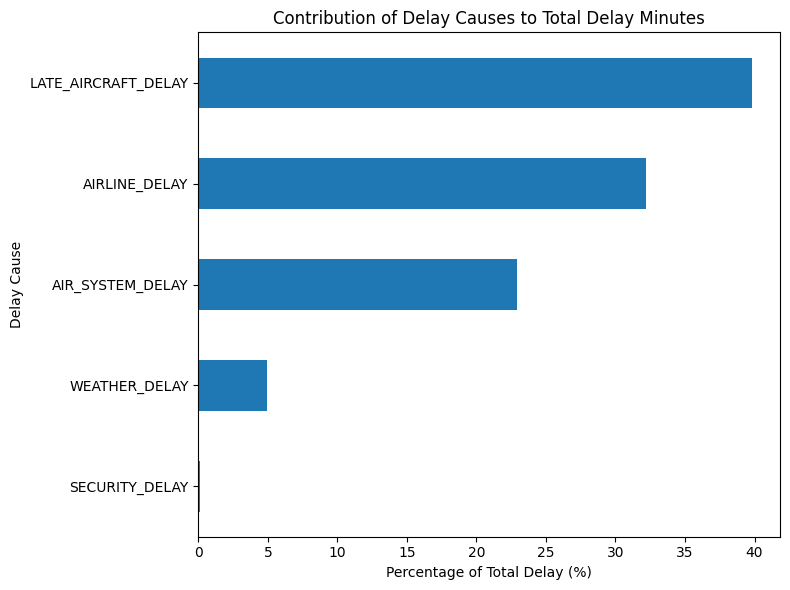

In [23]:
# Visualization of the root cause contribution 

plt.figure(figsize=(8, 6))

delay_cause_percentage.sort_values().plot(kind="barh")

plt.title("Contribution of Delay Causes to Total Delay Minutes")
plt.xlabel("Percentage of Total Delay (%)")
plt.ylabel("Delay Cause")
plt.tight_layout()

plt.show()

**Internal Operational Drivers (Primary Source of Delay)**

The largest contributors are:
- Late Aircraft Delay (39.84%)
- Airline Delay (32.2%)

Together, they account for **72.04% of total accumulated delay minutes.**

This indicates that the majority of delay time originates from internal airline operations and network propagation effects.
- Late aircraft delay suggests cascading delays across flight rotations.
- Airline delay reflects crew scheduling, boarding, maintenance, and ground handling inefficiencies.

This strongly suggests that delay accumulation is structurally embedded within the operational network rather than primarily driven by external shocks.

**System-Level Constraints (Moderate Impact)**

- Air System Delay (22.88%)

Nearly one quarter of total delay minutes are attributable to air traffic control, congestion, and infrastructure capacity constraints.

This highlights the role of:
- High-traffic hub congestion
- Airspace management limitations
- Structural capacity bottlenecks

**Environmental Factors (Limited Contribution)**

- Weather Delay (4.59%)

Weather contributes less than 5% of total delay minutes.

This suggests that although weather events can be disruptive when they occur, they are not the dominant systemic driver of delay accumulation across the dataset.

**Security-Related Disruptions (Negligible)**

- Security Delay (0.13%)

Security-related issues contribute a statistically negligible portion of total delay minutes, indicating minimal systemic impact. 

Overall, the analysis suggests that delay accumulation is primarily driven by internal operational dynamics and aircraft rotation effects rather than uncontrollable external factors. 

In [24]:
# Hub analysis
# Calculate average arrival delay and severe delay rate per hub

# Average arrival delay per origin airport
hub_avg_delay = completed_flights.groupby("AIRPORT_ORIGIN")["ARRIVAL_DELAY"].mean().round(2)

# Severe delay rate (>60 min) per hub
completed_flights["SEVERE_DELAY"] = (completed_flights["ARRIVAL_DELAY"] > 60).astype(int)
hub_severe_rate = (completed_flights.groupby("AIRPORT_ORIGIN")["SEVERE_DELAY"].mean() * 100).round(2)

# Combine into a single dataframe
hub_summary = pd.DataFrame({
    "Avg_Arrival_Delay": hub_avg_delay,
    "Severe_Delay_Rate": hub_severe_rate
})

# Show top 10 hubs by average delay
hub_summary.sort_values("Avg_Arrival_Delay", ascending=False).head(10)

,Avg_Arrival_Delay,Severe_Delay_Rate
AIRPORT_ORIGIN,,
Wilmington Airport,24.0600,14.7400
Gustavus Airport,21.7600,13.1600
Pago Pago International Airport (Tafuna Airport),21.5000,3.7700
St. Cloud Regional Airport,19.5600,11.6900
Jack Brooks Regional Airport (Southeast Texas Regional),16.1500,9.2800
Aspen-Pitkin County Airport,15.4900,11.8900
Southwest Oregon Regional Airport (North Bend Municipal),14.3300,12.1200
Martha's Vineyard Airport,12.9800,13.1700
Eagle County Regional Airport,12.4000,8.6800


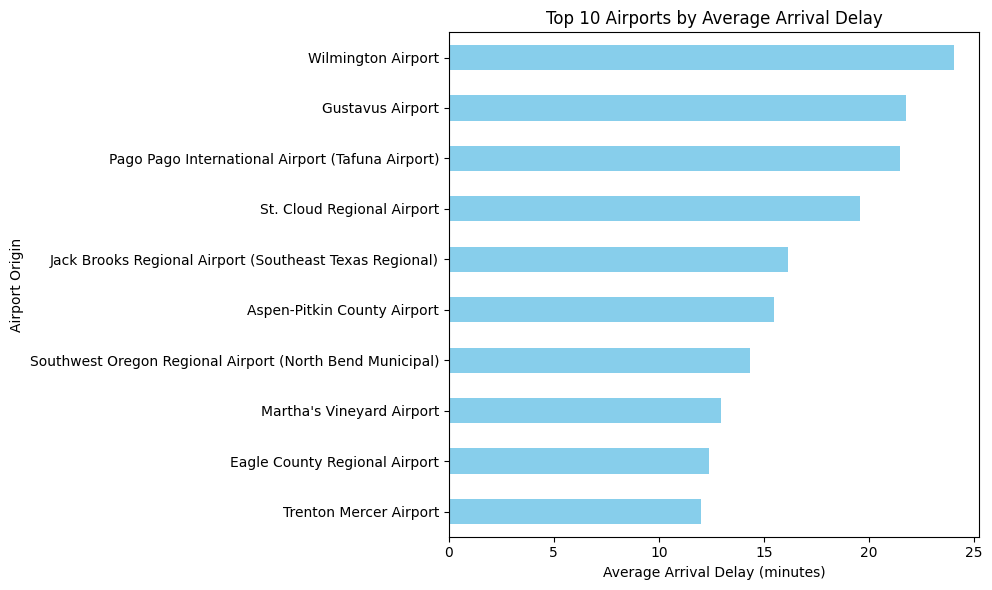

In [25]:
# Visualization of top hubs by average delay

# Top 10 airports by avg arrival delay
top_hubs = hub_summary.sort_values("Avg_Arrival_Delay", ascending=False).head(10)

plt.figure(figsize=(10,6))
top_hubs["Avg_Arrival_Delay"].plot(kind="barh", color="skyblue")
plt.title("Top 10 Airports by Average Arrival Delay")
plt.xlabel("Average Arrival Delay (minutes)")
plt.ylabel("Airport Origin")
plt.gca().invert_yaxis()  # Highest delay on top
plt.tight_layout()
plt.show()

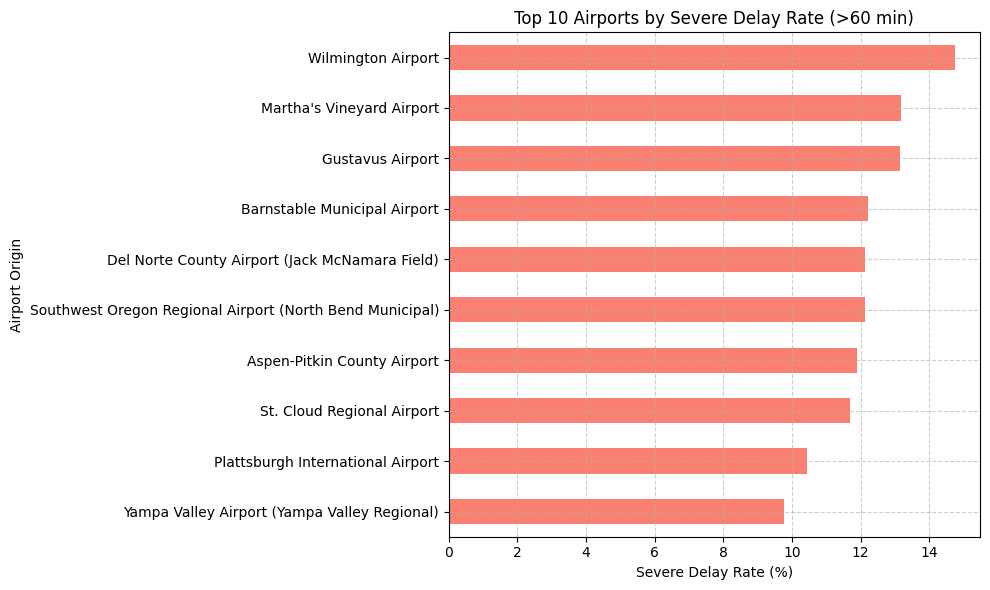

In [26]:
# Visualization for top 10 airports by severe delay rate (>60 min)

# Top 10 airports by severe delay rate 
top_hubs_severe = hub_summary.sort_values("Severe_Delay_Rate", ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_hubs_severe["Severe_Delay_Rate"].plot(kind="barh", color="salmon")
plt.title("Top 10 Airports by Severe Delay Rate (>60 min)")
plt.xlabel("Severe Delay Rate (%)")
plt.ylabel("Airport Origin")
plt.gca().invert_yaxis()  # Highest rate on top
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Hub Analysis Interpretation**

**High-Delay Regional Hubs**
Airports such as **Wilmington Airport (Avg Delay 24.06 min, Severe Delay Rate 14.74%)** and **Gustavus Airport (21.76 min, 13.16%)** show the highest average arrival delays and severe delay rates. This indicates that these regional hubs, despite lower traffic than major international airports, are more prone to operational delays, possibly due to limited infrastructure, fewer backup resources, and sensitivity to cascading network disruptions.

**Medium-Delay Hubs**
Airports like **St. Cloud Regional Airport** and **Aspen-Pitkin Country Airport** exhibit moderate average delays (≈15–20 min) with severe delay rates around 10-12%. These hubs may experience delays driven by both operational inefficiencies and environmental factors, such as weather or terrain-related disruptions.

**Lower-Delay Hubs**
Airports such as **Trenton Mercer Airport (11.99 min, 9.02%)** and **Eagle County Regional Airport (12.40 min, 8.68%)** have comparatively lower delays, suggesting more stable operations or less susceptibility to delay propagation.

**Overall Insight**
The results highlight that **average delay and severe delay rates vary significantly across hubs,** with smaller or remote airports often showing higher sensitivity to disruptions. This aligns with the root cause analysis, as delays are amplified at airports with limited operational capacity, reflecting both internal network propagation and system-level constraints. 

In [27]:
completed_flights.to_csv('../data/joint_dataset_operationalperformancemetrics.csv', index=False)